In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Set theme seaborn global
sns.set_theme(
    style="whitegrid",
    font="sans-serif",
    rc={
        "figure.figsize": (8, 5),
        "axes.edgecolor": "#EAEAEA",
        "grid.color": "#686D76",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11
    }
)

In [2]:
# dari CSV
df = pd.read_csv("../data/CLEAN_bank_customer_churn.csv")
display(df.head())

memory_mb = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Memory usage: {memory_mb:.2f} MB")

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Memory usage: 0.94 MB


In [3]:
print('== Dataset Profile ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')

print('== Missing Values ==')
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Total': missing_count,
    'Percentage(%)': missing_pct
})
missing_summary = missing_summary[missing_summary['Total'] > 0].sort_values(by='Total', ascending=False)
print(missing_summary if not missing_summary.empty else 'No missing values found', '\n')

print('== Duplicate Data ==')
print(f'Total Duplicates : {df.duplicated().sum()}\nDuplicate Percentage : {(df.duplicated().sum()/len(df)*100).round(2)}\n')

print('== Column Data Types ==')
print(df.dtypes)

== Dataset Profile ==
Baris: 10000
Kolom: 11 

== Missing Values ==
No missing values found 

== Duplicate Data ==
Total Duplicates : 0
Duplicate Percentage : 0.0

== Column Data Types ==
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [4]:
from sklearn.model_selection import train_test_split

target_col = 'Exited'

X = df.drop(columns=[target_col])
y = df[target_col]

# Pembagian 80:20 - Train dan Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

total_len = len(df)
print(f"Train set   : {len(X_train)} baris ({len(X_train)/total_len:.0%})")
print(f"Test set    : {len(X_test)} baris ({len(X_test)/total_len:.0%})")
print("\nDistribusi target di Train:")
print((y_train.value_counts(normalize=True) * 100).round(1))
print("\nDistribusi target di Test:")
print((y_test.value_counts(normalize=True) * 100).round(1))
display(X_train.head())

Train set   : 8000 baris (80%)
Test set    : 2000 baris (20%)

Distribusi target di Train:
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64

Distribusi target di Test:
Exited
0    79.6
1    20.3
Name: proportion, dtype: float64


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2151,753,France,Male,57,7,0.00,1,1,0,159475.08
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25
4117,561,France,Male,37,5,0.00,2,1,0,83093.25
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99


---
# **Encoding & Scaling**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Auto-detect
ohe_features = X_train.select_dtypes(include=['object', 'str', 'category']).columns.tolist()

# fitur numerik
all_num = X_train.select_dtypes(include=[int, float]).columns.tolist()
binary_features = [col for col in all_num if X_train[col].nunique() <= 2]
num_features = [col for col in all_num if col not in binary_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), ohe_features),
        ('bin', 'passthrough', binary_features)
    ]
)

display(preprocessor)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

---
# **Modeling**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score, recall_score, f1_score,   # tambahkan average='macro'/'weighted' untuk multi-class
    roc_auc_score, roc_curve,                  # khusus binary (atau multi_class='ovr' untuk multi-class)
)

In [7]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight= 'balanced', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight= 'balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio)
}

**Cross Validation**

In [8]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING = 'f1'

cv_results = []
for name, model in models.items():
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring=SCORING, n_jobs=-1)
    cv_results.append({'Model': name, f'Mean {SCORING}': scores.mean(), f'Std {SCORING}': scores.std()})
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_results_df = pd.DataFrame(cv_results).sort_values(f'Mean {SCORING}', ascending=False)
print("\n== Ringkasan CV — Perbandingan Model Baseline ==")
print(cv_results_df)

Logistic Regression: 0.4883 (+/- 0.0196)
Random Forest: 0.5994 (+/- 0.0334)
XGBoost: 0.5843 (+/- 0.0217)

== Ringkasan CV — Perbandingan Model Baseline ==
                 Model   Mean f1    Std f1
1        Random Forest  0.599394  0.033424
2              XGBoost  0.584278  0.021653
0  Logistic Regression  0.488284  0.019617


**Insight**<br>

Random Forest dan XGBosst mengungguli Logistic Regression, mengindikasikan hubungan fitur dengan churn bersifat non-linear. RF unggul tipis dari XGBoost tapi std-nya lebih tinggi (0.03 vs 0.02). RF lebih tinggi rata-rata, XGBoost lebih stabil antar fold.

**Hyperparameter Tuning**

Random Forest

In [9]:
from sklearn.model_selection import RandomizedSearchCV

pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight= 'balanced'))
])

param_grid_rf = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(pipeline, param_grid_rf, n_iter=20, cv=skf, scoring=SCORING,
                             n_jobs=-1, random_state=42, verbose=1)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV {SCORING} score:", search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None}
Best CV f1 score: 0.6195832047796132


**Insight**<br>

Tuning menaikkan F1 dari 0.599 ke 0.620. Parameter max depth = None terpilih, artinya model membangun pohon yang cukup dalam untuk menangkap pola non-linear.

#### **Re-Train Model**

In [10]:
final_pipeline = search.best_estimator_

print("Model selesai di-retrain!")

y_pred = final_pipeline.predict(X_test)

y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

print("--- Evaluasi Model Tambahan ---")
print(f"Accuracy Score  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score : {precision_score(y_test, y_pred):.4f}")
print(f"Recall Score    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score        : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score   : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model selesai di-retrain!
--- Evaluasi Model Tambahan ---
Accuracy Score  : 0.8425
Precision Score : 0.6036
Recall Score    : 0.6585
F1 Score        : 0.6298
ROC-AUC Score   : 0.8549

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



**Insight**<br>

F1 test lebih tinggi dari F1 CV, tanda model tidak overfitting, generalisasinya konsisten. Recall lebih tinggi dari precision, artinya model lebih agresif menandai nasabah sebagai calon churn (banyak false positif, sedikit false negatif). Menguntungkan secara bisnis karena lebih baik salah waspada daripada gagal mendeteksi nasabah yang benar-benar akan pergi. ROC-AUC 0.855 menunjukkan kemampuan diskriminasi model tergolong baik.

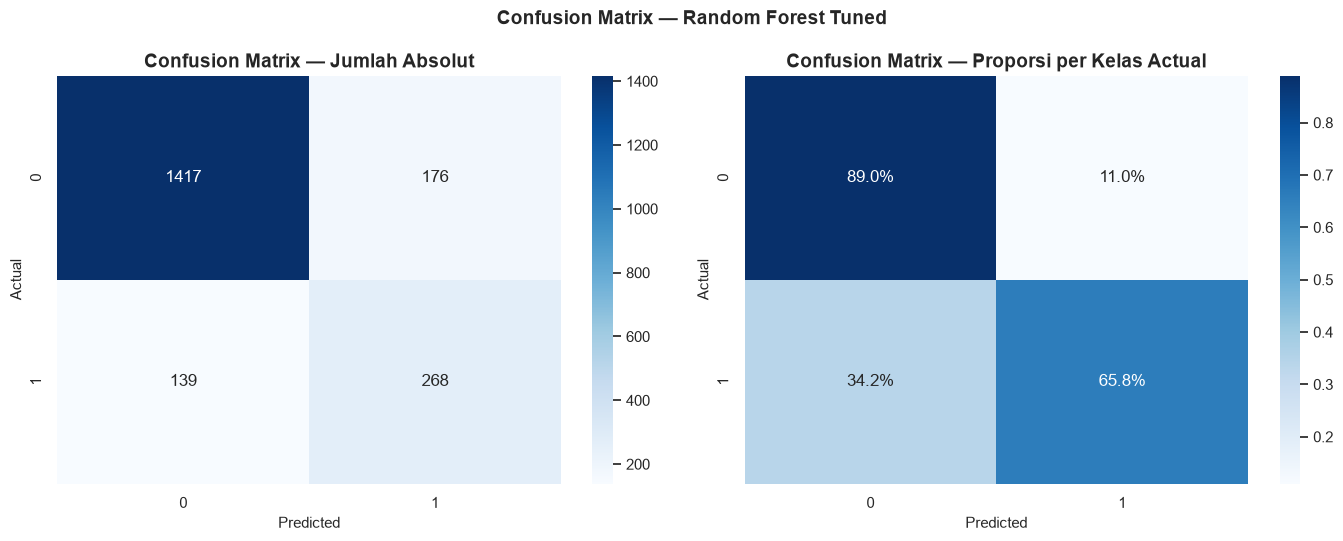

In [11]:
label_order = [0, 1]

cm = confusion_matrix(y_test, y_pred, labels=label_order)
cm_normalized = confusion_matrix(y_test, y_pred, labels=label_order, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Kiri: jumlah absolut
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order, ax=axes[0])
axes[0].set_title('Confusion Matrix — Jumlah Absolut')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Kanan: proporsi per baris (persentase dari actual class)
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order, ax=axes[1])
axes[1].set_title('Confusion Matrix — Proporsi per Kelas Actual')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle(f'Confusion Matrix — Random Forest Tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/08_confusion_matrix_rftuned.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Feature Importance**

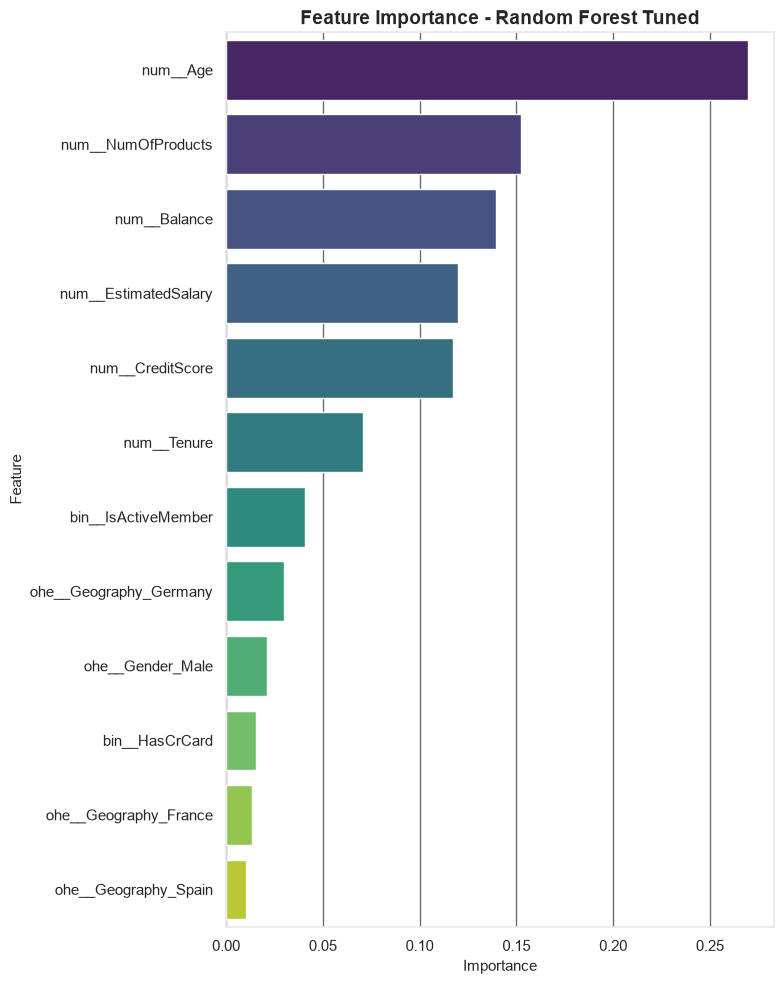

               Feature  Importance
              num__Age    0.269611
    num__NumOfProducts    0.152207
          num__Balance    0.139346
  num__EstimatedSalary    0.119879
      num__CreditScore    0.117455
           num__Tenure    0.070868
   bin__IsActiveMember    0.040664
ohe__Geography_Germany    0.029764
      ohe__Gender_Male    0.021309
        bin__HasCrCard    0.015707
 ohe__Geography_France    0.013146
  ohe__Geography_Spain    0.010044


In [12]:
# Ekstrak preprocessor dan model yang SUDAH DILATIH dari dalam pipeline
fitted_preprocessor = final_pipeline.named_steps['preprocessor']
fitted_model = final_pipeline.named_steps['model']

# Ambil nama fitur hasil transform
feature_names = fitted_preprocessor.get_feature_names_out()

# Bikin DataFrame importance, urutkan dari terbesar
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': fitted_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisasi
plt.figure(figsize=(8, 10))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature',
            palette='viridis', legend=False)
plt.title('Feature Importance - Random Forest Tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/09_feature_importance_rftuned.png', dpi=150, bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))

**Insight**<br>

Age mendominasi (0.27, hampir 2x fitur kedua), disusul NumOfProducts dan Balance. Fitur kategorikal (Geography, Gender, HasCrCard) berada di peringkat bawah, meski di EDA Germany dan Female terlihat punya churn rate lebih tinggi, kontribusinya ke model kalah jauh dibanding fitur numerik.

#### **SHAP**

In [13]:
import shap

fitted_preprocessor = final_pipeline.named_steps['preprocessor']    # ganti dan sesuaikan nama pipeline
fitted_model = final_pipeline.named_steps['model']

X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)  # sample biar cepat, boleh pakai X_test penuh kalau datanya kecil
X_sample_transformed = fitted_preprocessor.transform(X_sample)
feature_names = fitted_preprocessor.get_feature_names_out()
X_sample_df = pd.DataFrame(X_sample_transformed, columns=feature_names, index=X_sample.index)

target_class = 1  # kelas positif yang mau dijelaskan (misal: churn/tidak puas)

explainer = shap.TreeExplainer(fitted_model)
shap_values_raw = explainer.shap_values(X_sample_df)

if isinstance(shap_values_raw, list):                          # format list [kelas0, kelas1]
    shap_values = shap_values_raw[target_class]
    base_value = explainer.expected_value[target_class]
elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:  # format 3D
    shap_values = shap_values_raw[:, :, target_class]
    expected = explainer.expected_value
    base_value = expected[target_class] if hasattr(expected, '__len__') else expected
else:                                                            # format 2D biasa
    shap_values = shap_values_raw
    base_value = explainer.expected_value

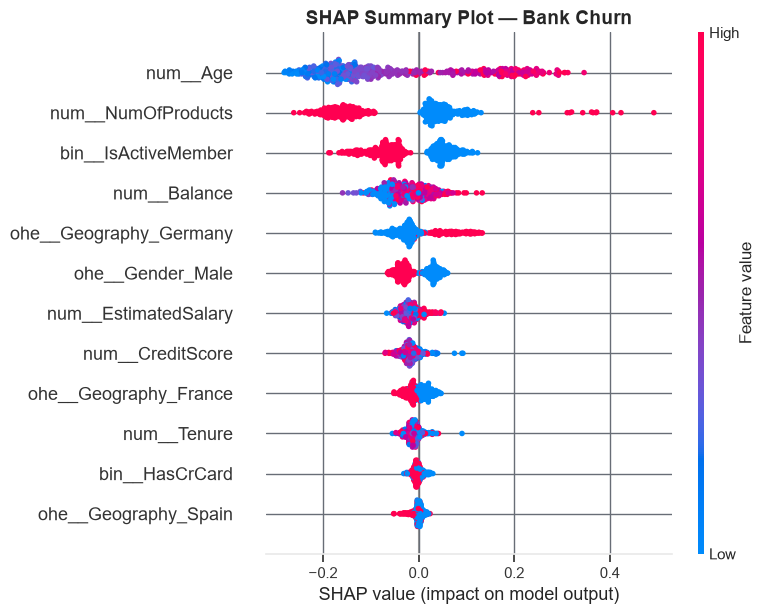

In [14]:
shap.summary_plot(shap_values, X_sample_df, plot_type='dot', max_display=15, show=False)
plt.title('SHAP Summary Plot — Bank Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/10_SHAP_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight**<br>

Mengonfirmasi arah pengaruh tiap fitur, nilai Age tinggi konsisten mendorong prediksi ke arah churn, begitu juga NumOfProducts dan Balance. Nasabah dengan produk banyak dan saldo lebih besar justru cenderung berisiko churn lebih tinggi.

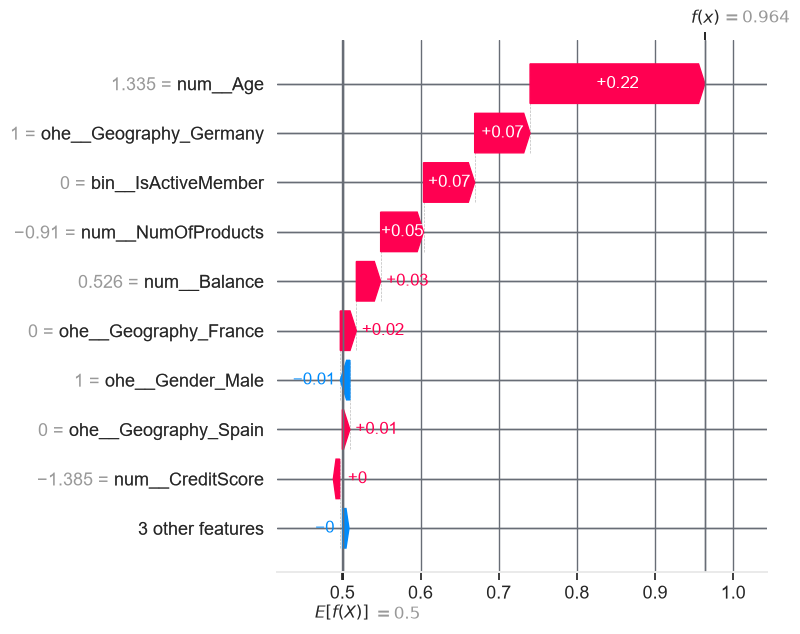

In [15]:
proba = fitted_model.predict_proba(X_sample_df.values)[:, 1]
idx_most_positive = int(np.argmax(proba))            # paling yakin kelas 1
idx_most_negative = int(np.argmin(proba))             # paling yakin kelas 0
idx_most_uncertain = int(np.argmin(np.abs(proba - 0.5)))  # model paling ragu

idx = idx_most_positive  # ganti sesuai kasus yang mau dijelaskan
 
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_sample_df.iloc[idx],
        feature_names=feature_names
    ),
    show=False
)
plt.tight_layout()
plt.savefig('../assets/11_SHAP_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight**<br>

Menunjukkan breakdown kontribusi tiap fitur untuk kasus nasabah dengan probabilitas churn tertinggi, melengkapi summary plot dengan studi kasus konkret.

#### **Re-Train Model DATA FULL**

In [16]:
best_params = search.best_params_

X_all = pd.concat([X_train, X_test]).reset_index(drop=True)
y_all = pd.concat([y_train, y_test]).reset_index(drop=True)

X_full, X_sanity, y_full, y_sanity = train_test_split(
    X_all, y_all,
    test_size=0.05,
    stratify=y_all,
    random_state=42
)

final_pipeline_full = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight= 'balanced'))
])

final_pipeline_full.set_params(**best_params)
final_pipeline_full.fit(X_full, y_full)

print("Model selesai di-retrain!")
print(f"Data training: {len(X_full)} baris | Data sanity check: {len(X_sanity)} baris")

Model selesai di-retrain!
Data training: 9500 baris | Data sanity check: 500 baris


---
# **Save Model**

In [17]:
import joblib

nama_model = 'final_pipeline_rftuned.pkl'

joblib.dump(final_pipeline_full, f'../models/{nama_model}')
print("Model tersimpan!\n")

# Quick sanity check - load ulang, pastikan bisa predict tanpa error
loaded_test = joblib.load(f'../models/{nama_model}')
sanity_pred = loaded_test.predict(X_sanity)
sanity_proba = loaded_test.predict_proba(X_sanity)[:, 1]

print("--- Sanity Check ---")
print(f"Accuracy  : {accuracy_score(y_sanity, sanity_pred):.4f}")
print(f"F1 Score  : {f1_score(y_sanity, sanity_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_sanity, sanity_proba):.4f}")
print("\nPrediksi 5 sample pertama:", sanity_pred[:5])
print("Aktual 5 sample pertama  :", y_sanity.values[:5])

Model tersimpan!

--- Sanity Check ---
Accuracy  : 0.8480
F1 Score  : 0.6082
ROC-AUC   : 0.8452

Prediksi 5 sample pertama: [0 0 0 0 0]
Aktual 5 sample pertama  : [0 0 0 0 0]
